<a href="https://colab.research.google.com/github/MaggieHDez/ClassFiles/blob/main/pronosticoTasaDeNatalidad.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Obtención de los datos y conversión al formato adecuado

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd

# =========================================================
# 1. CARGA Y LIMPIEZA DEL ARCHIVO DE NACIMIENTOS
# =========================================================

path_nac = "/content/drive/MyDrive/ClassFiles/Proyecto/ENR_estatal_total.csv"

# Limpiar bytes nulos
with open(path_nac, "rb") as f:
    raw = f.read()
clean = raw.replace(b"\x00", b"")

clean_path_nac = "/content/drive/MyDrive/ClassFiles/Proyecto/ENR_Estatal_total_clean.csv"
with open(clean_path_nac, "wb") as f:
    f.write(clean)

# Leer CSV
df = pd.read_csv(clean_path_nac, sep=",", encoding="latin1")
df.columns = df.columns.str.strip()

# Quitar columnas innecesarias
df = df.drop(columns=["Unnamed: 33"], errors="ignore")
df = df.drop(columns=["Indicador"], errors="ignore")

# Limpiar filas sin estado
df = df[df["Área geográfica"].notna()]
df["Área geográfica"] = df["Área geográfica"].astype(str).str.strip()
df = df[df["Área geográfica"] != ""]

# Conversión a formato largo (tidy)
df_long = df.melt(
    id_vars=["Área geográfica"],
    var_name="ano",
    value_name="nacimientos"
).rename(columns={"Área geográfica": "estado"})

# Tipos y filtros
df_long["ano"] = pd.to_numeric(df_long["ano"], errors="coerce")
df_long["nacimientos"] = pd.to_numeric(df_long["nacimientos"], errors="coerce")

df_long = df_long[df_long["ano"].between(1994, 2024)]
df_long = df_long[df_long["nacimientos"].notna()]

# Checks del dataset estatal tidy
cols, rows = df_long.shape
print("=== NACIMIENTOS ESTATALES TIDY ===")
print("Variables:", cols)
print("Observaciones:", rows)
print("Estados:", df_long["estado"].nunique())
print("Años:", int(df_long["ano"].min()), int(df_long["ano"].max()))
print(df_long.info())
print(df_long.describe())

# Guardar archivo estatal tidy
df_long.to_csv(
    "/content/drive/MyDrive/ClassFiles/Proyecto/enr_estatal_tidy_1994_2024.csv",
    index=False
)


# =========================================================
# 2. AGREGAR NACIMIENTOS A NIVEL NACIONAL
# =========================================================

df_nac_nacional = (
    df_long.groupby("ano", as_index=False)["nacimientos"]
    .sum()
    .rename(columns={"nacimientos": "nacimientos_totales"})
)

print("\n=== NACIMIENTOS NACIONALES ===")
print(df_nac_nacional.head())


# =========================================================
# 3. CARGA Y LIMPIEZA DEL ARCHIVO DE POBLACIÓN TOTAL (WORLD BANK)
# =========================================================

path_pob = "/content/drive/MyDrive/ClassFiles/Proyecto/d088dfd4-3c05-49d3-822b-92ccb32b1faa_Data.csv"

df_pob_raw = pd.read_csv(path_pob)
df_pob_raw.columns = df_pob_raw.columns.str.strip()

print("\n=== COLUMNAS DEL WORLD BANK ===")
print(df_pob_raw.columns.tolist())

# Filtrar solo México y la serie "Population, total"
df_pob_raw = df_pob_raw[
    (df_pob_raw["Country Name"] == "Mexico") &
    (df_pob_raw["Series Name"] == "Population, total")
].copy()

# Identificar columnas de años
year_cols = [col for col in df_pob_raw.columns if "[YR" in col]

# Convertir a formato largo
df_pob = df_pob_raw.melt(
    id_vars=["Country Name", "Series Name"],
    value_vars=year_cols,
    var_name="ano",
    value_name="poblacion_total"
)

# Extraer año
df_pob["ano"] = df_pob["ano"].str.extract(r"(\d{4})")
df_pob["ano"] = pd.to_numeric(df_pob["ano"], errors="coerce")

# Convertir población a numérico
df_pob["poblacion_total"] = pd.to_numeric(df_pob["poblacion_total"], errors="coerce")

# Filtrar periodo y valores válidos
df_pob = df_pob[df_pob["ano"].between(1994, 2024)]
df_pob = df_pob[df_pob["poblacion_total"].notna()]

# Quedarse con columnas finales
df_pob = df_pob[["ano", "poblacion_total"]].sort_values("ano").reset_index(drop=True)

print("\n=== POBLACIÓN TOTAL DE MÉXICO ===")
print(df_pob.head())
print(df_pob.tail())
print("Registros:", len(df_pob))

# Guardar población tidy
df_pob.to_csv(
    "/content/drive/MyDrive/ClassFiles/Proyecto/poblacion_total_mexico_1994_2024.csv",
    index=False
)


# =========================================================
# 4. INTEGRACIÓN DE FUENTES Y CÁLCULO DE TASA DE NATALIDAD
# =========================================================

df_tasa = pd.merge(df_nac_nacional, df_pob, on="ano", how="inner")

df_tasa["tasa_natalidad"] = (
    df_tasa["nacimientos_totales"] / df_tasa["poblacion_total"]
) * 1000

df_tasa = df_tasa.sort_values("ano").reset_index(drop=True)

print("\n=== SERIE FINAL DE TASA DE NATALIDAD ===")
print(df_tasa.head())
print(df_tasa.tail())
print(df_tasa.info())
print(df_tasa.describe())

# Guardar archivo final para modelado
df_tasa.to_csv(
    "/content/drive/MyDrive/ClassFiles/Proyecto/tasa_natalidad_mexico_1994_2024.csv",
    index=False
)

=== NACIMIENTOS ESTATALES TIDY ===
Variables: 992
Observaciones: 3
Estados: 32
Años: 1994 2024
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 992 entries, 0 to 991
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   estado       992 non-null    object 
 1   ano          992 non-null    int64  
 2   nacimientos  992 non-null    float64
dtypes: float64(1), int64(1), object(1)
memory usage: 23.4+ KB
None
               ano    nacimientos
count   992.000000     992.000000
mean   2009.000000   76093.665323
std       8.948784   63319.112072
min    1994.000000    8049.000000
25%    2001.000000   33143.750000
50%    2009.000000   57139.000000
75%    2017.000000  104415.000000
max    2024.000000  355392.000000

=== NACIMIENTOS NACIONALES ===
    ano  nacimientos_totales
0  1994            2901877.0
1  1995            2747772.0
2  1996            2705170.0
3  1997            2697405.0
4  1998            2663905.0

=== COLUMN

## Análisis exploratorio de datos (EDA)


--- INFORMACIÓN GENERAL ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 992 entries, 0 to 991
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   estado       992 non-null    object 
 1   ano          992 non-null    int64  
 2   nacimientos  992 non-null    float64
dtypes: float64(1), int64(1), object(1)
memory usage: 23.4+ KB
None

--- ESTADÍSTICA DESCRIPTIVA ---
               ano    nacimientos
count   992.000000     992.000000
mean   2009.000000   76093.665323
std       8.948784   63319.112072
min    1994.000000    8049.000000
25%    2001.000000   33143.750000
50%    2009.000000   57139.000000
75%    2017.000000  104415.000000
max    2024.000000  355392.000000

Shape: (992, 3)

--- NULOS ---
estado         0
ano            0
nacimientos    0
dtype: int64

Duplicados: 0
Duplicados (estado, año): 0
=== INFORMACIÓN DATASET WORLD BANK ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31 entries, 0 to 30
Da

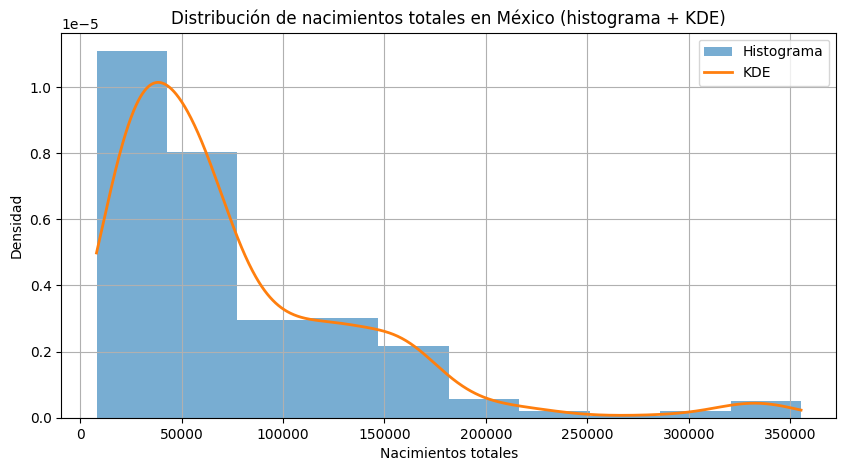

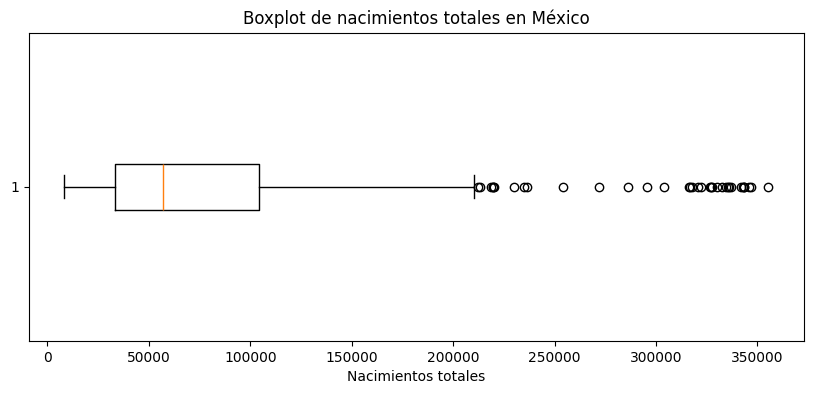

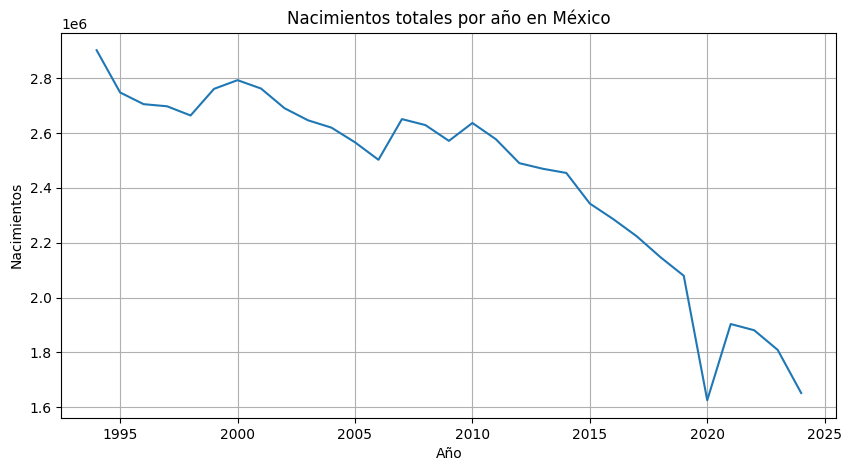

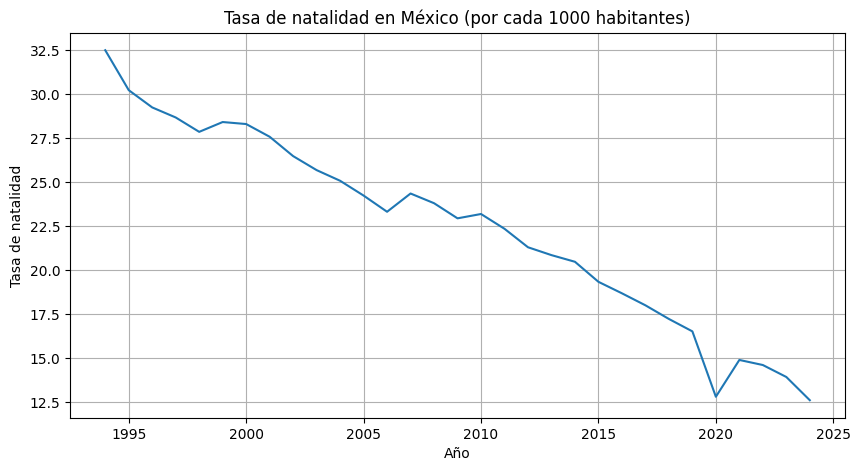

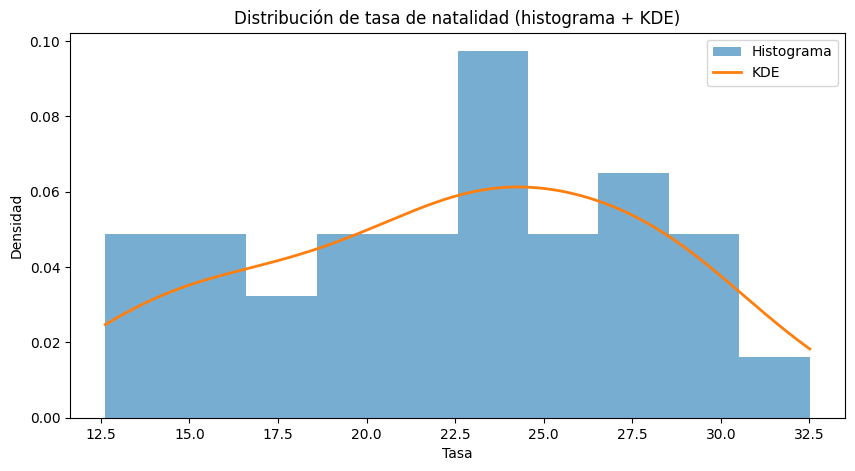

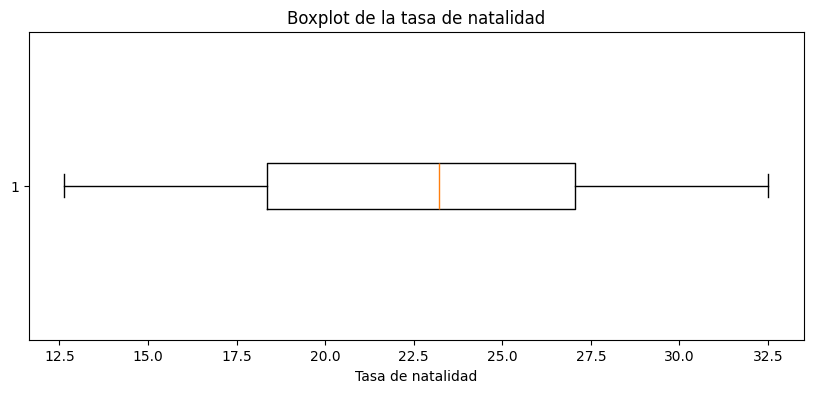

=== INFORMACIÓN DATASET INTEGRADO (TASA DE NATALIDAD) ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31 entries, 0 to 30
Data columns (total 4 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ano                  31 non-null     int64  
 1   nacimientos_totales  31 non-null     float64
 2   poblacion_total      31 non-null     float64
 3   tasa_natalidad       31 non-null     float64
dtypes: float64(3), int64(1)
memory usage: 1.1 KB
None
               ano  nacimientos_totales  poblacion_total  tasa_natalidad
count    31.000000         3.100000e+01     3.100000e+01       31.000000
mean   2009.000000         2.434997e+06     1.114736e+08       22.449260
std       9.092121         3.521344e+05     1.291929e+07        5.508877
min    1994.000000         1.625527e+06     8.925920e+07       12.622828
25%    2001.500000         2.254524e+06     1.008239e+08       18.357072
50%    2009.000000         2.571307e+06     1.1

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

# =========================================================
# COPIAS DE LOS DATASETS PARA ANÁLISIS EXPLORATORIO
# =========================================================
# df_eda: dataset de nacimientos por estado (formato tidy)
# df_tasa_eda: dataset agregado nacional con tasa de natalidad

df_eda = df_long.copy()
df_tasa_eda = df_tasa.copy()


# =========================================================
# INFORMACIÓN GENERAL DEL DATASET DE NACIMIENTO
# =========================================================
# Se revisa la estructura, tipos de datos y posibles inconsistencias

print("\n--- INFORMACIÓN GENERAL ---")
print(df_eda.info())

# Estadística descriptiva de todas las variables numéricas
print("\n--- ESTADÍSTICA DESCRIPTIVA ---")
print(df_eda.describe())

# Dimensiones del dataset
print("\nShape:", df_eda.shape)

# Conteo de valores nulos por columna
print("\n--- NULOS ---")
print(df_eda.isna().sum())

# Identificación de registros duplicados
print("\nDuplicados:", df_eda.duplicated().sum())
print("Duplicados (estado, año):", df_eda.duplicated(subset=["estado","ano"]).sum())

# =========================================================
# INFORMACIÓN GENERAL DEL DATASET DE WORLD BANK
# =========================================================

print("=== INFORMACIÓN DATASET WORLD BANK ===")
print(df_pob.info())
print(df_pob.describe())
print("Registros:", len(df_pob))
print("Años:", int(df_pob["ano"].min()), int(df_pob["ano"].max()))
print("Valores faltantes:", df_pob.isna().sum())

# =========================================================
# DISTRIBUCIÓN DE NACIMIENTOS TOTALES (HISTOGRAMA + KDE)
# =========================================================

data_nac = df_eda["nacimientos"].dropna()

x = np.linspace(data_nac.min(), data_nac.max(), 1000)
kde = gaussian_kde(data_nac)

plt.figure(figsize=(10,5))
plt.hist(data_nac, bins=10, density=True, alpha=0.6, label="Histograma")
plt.plot(x, kde(x), linewidth=2, label="KDE")
plt.title("Distribución de nacimientos totales en México (histograma + KDE)")
plt.xlabel("Nacimientos totales")
plt.ylabel("Densidad")
plt.legend()
plt.grid()
plt.show()

# =========================================================
# BOXPLOT DE NACIMIENTOS TOTALES
# =========================================================

plt.figure(figsize=(10,4))
plt.boxplot(data_nac, vert=False)
plt.title("Boxplot de nacimientos totales en México")
plt.xlabel("Nacimientos totales")
plt.show()


# =========================================================
# SERIE NACIONAL DE NACIMIENTOS
# =========================================================
# Se agregan los nacimientos por año (suma de estados)

serie_nacional = (
    df_eda.groupby("ano", as_index=False)["nacimientos"]
    .sum()
    .sort_values("ano")
)

plt.figure(figsize=(10,5))
plt.plot(serie_nacional["ano"], serie_nacional["nacimientos"])
plt.title("Nacimientos totales por año en México")
plt.xlabel("Año")
plt.ylabel("Nacimientos")
plt.grid()
plt.show()

# =========================================================
# SERIE DE TASA DE NATALIDAD (VARIABLE OBJETIVO)
# =========================================================
# Se analiza la serie final que será utilizada en el modelado

plt.figure(figsize=(10,5))
plt.plot(df_tasa_eda["ano"], df_tasa_eda["tasa_natalidad"])
plt.title("Tasa de natalidad en México (por cada 1000 habitantes)")
plt.xlabel("Año")
plt.ylabel("Tasa de natalidad")
plt.grid()
plt.show()

# =========================================================
# DISTRIBUCIÓN DE TASA (HISTOGRAMA + KDE)
# =========================================================
# Se analiza la distribución de la variable objetivo (nacimientos)

data = df_tasa_eda["tasa_natalidad"].dropna()

# Generación de valores para la curva de densidad
x = np.linspace(data.min(), data.max(), 1000)

# Estimación de densidad (KDE)
kde = gaussian_kde(data)

plt.figure(figsize=(10,5))
plt.hist(data, bins=10, density=True, alpha=0.6, label="Histograma")
plt.plot(x, kde(x), linewidth=2, label="KDE")
plt.title("Distribución de tasa de natalidad (histograma + KDE)")
plt.xlabel("Tasa")
plt.ylabel("Densidad")
plt.legend()
plt.show()

# =========================================================
# BOXPLOT DE LA TASA DE NATALIDAD
# =========================================================
# Permite observar la dispersión de la variable objetivo

plt.figure(figsize=(10,4))
plt.boxplot(df_tasa_eda["tasa_natalidad"].dropna(), vert=False)
plt.title("Boxplot de la tasa de natalidad")
plt.xlabel("Tasa de natalidad")
plt.show()

# =========================================================
# INFORMACIÓN DEL DATASET INTEGRADO
# =========================================================
print("=== INFORMACIÓN DATASET INTEGRADO (TASA DE NATALIDAD) ===")
print(df_tasa.info())
print(df_tasa.describe())
print("Valores faltantes:", df_tasa.isna().sum())

## Implementación, ajuste y evaluación de modelos de pronóstico

Serie final:
fecha
1994-01-01    32.510675
1995-01-01    30.241005
1996-01-01    29.260043
1997-01-01    28.689325
1998-01-01    27.872332
Freq: YS-JAN, Name: tasa_natalidad, dtype: float64
fecha
2020-01-01    12.819709
2021-01-01    14.911246
2022-01-01    14.623065
2023-01-01    13.943482
2024-01-01    12.622828
Freq: YS-JAN, Name: tasa_natalidad, dtype: float64
Observaciones: 31


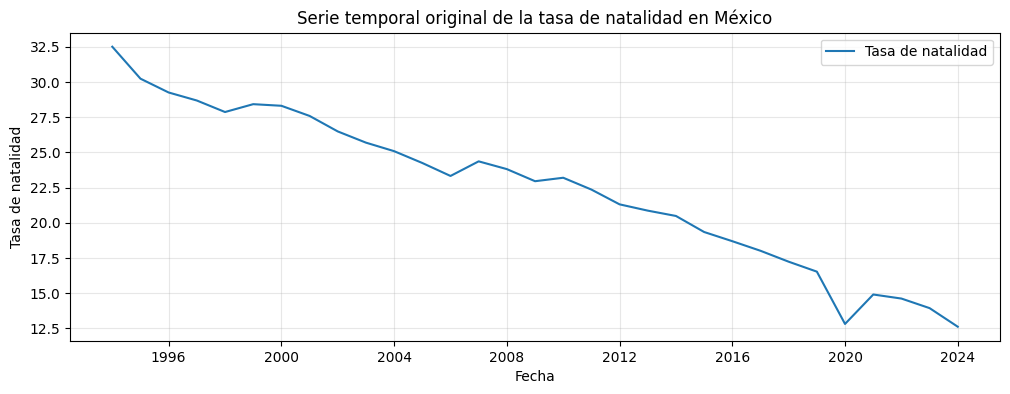

------------------------------------
Pruebas de estacionariedad para la serie original
===> Test: ADF
H0: Serie NO estacionaria
H1: Serie estacionaria
p-value: 0.963692
NO se rechaza H0
No hay evidencia suficiente contra: Serie NO estacionaria

===> Test: KPSS
H0: Serie estacionaria
H1: Serie NO estacionaria
p-value: 0.010000
Se RECHAZA H0
Evidencia a favor de: Serie NO estacionaria

------------------------------------
Serie diferenciada de primer orden


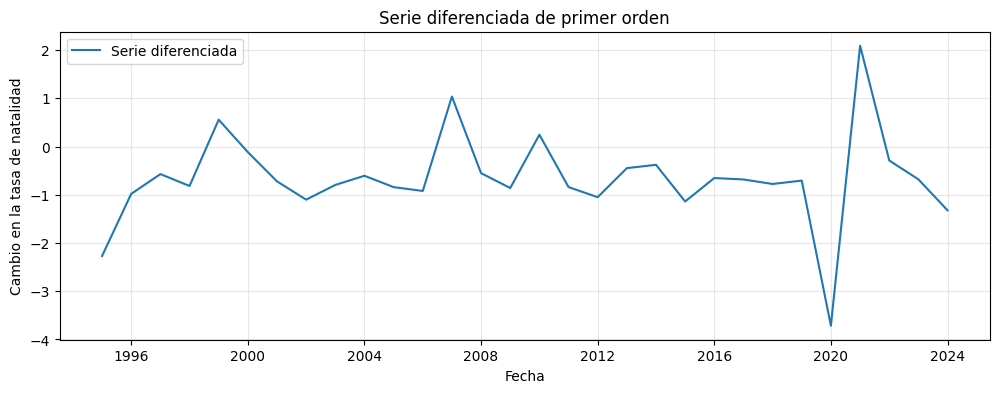

Pruebas de estacionariedad para la serie diferenciada
===> Test: ADF
H0: Serie NO estacionaria
H1: Serie estacionaria
p-value: 0.000000
Se RECHAZA H0
Evidencia a favor de: Serie estacionaria

===> Test: KPSS
H0: Serie estacionaria
H1: Serie NO estacionaria
p-value: 0.100000
NO se rechaza H0
No hay evidencia suficiente contra: Serie estacionaria

------------------------------------


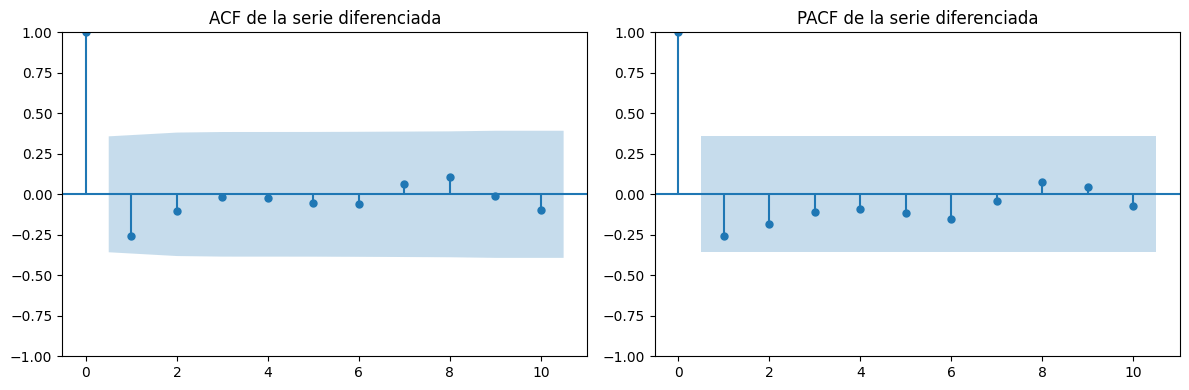

ACF:
Lag 0: 1.0000
Lag 1: -0.2595
Lag 2: -0.1022
Lag 3: -0.0188
Lag 4: -0.0256
Lag 5: -0.0538
Lag 6: -0.0619
Lag 7: 0.0663
Lag 8: 0.1068
Lag 9: -0.0102
Lag 10: -0.0983
PACF:
Lag 0: 1.0000
Lag 1: -0.2595
Lag 2: -0.1818
Lag 3: -0.1079
Lag 4: -0.0916
Lag 5: -0.1184
Lag 6: -0.1540
Lag 7: -0.0429
Lag 8: 0.0790
Lag 9: 0.0458
Lag 10: -0.0740
------------------------------------
Tamaño train: 24
Tamaño test: 7
Inicio train: 1994-01-01 00:00:00  Fin train: 2017-01-01 00:00:00
Inicio test: 2018-01-01 00:00:00  Fin test: 2024-01-01 00:00:00
------------------------------------
Modelos ordenados por AIC y BIC:
         Modelo        AIC        BIC
0           DES -15.275003 -10.562788
1           SES  -2.594040  -0.237932
2  ARIMA(1,1,1)  54.065546  57.472029
3  ARIMA(2,1,2)  55.767618  61.445089
4  ARIMA(1,1,2)  55.817658  60.359635
5  ARIMA(2,1,1)  55.932428  60.474405
------------------------------------
Métricas de desempeño:
             Modelo       MAE        MSE      RMSE       MAPE      s

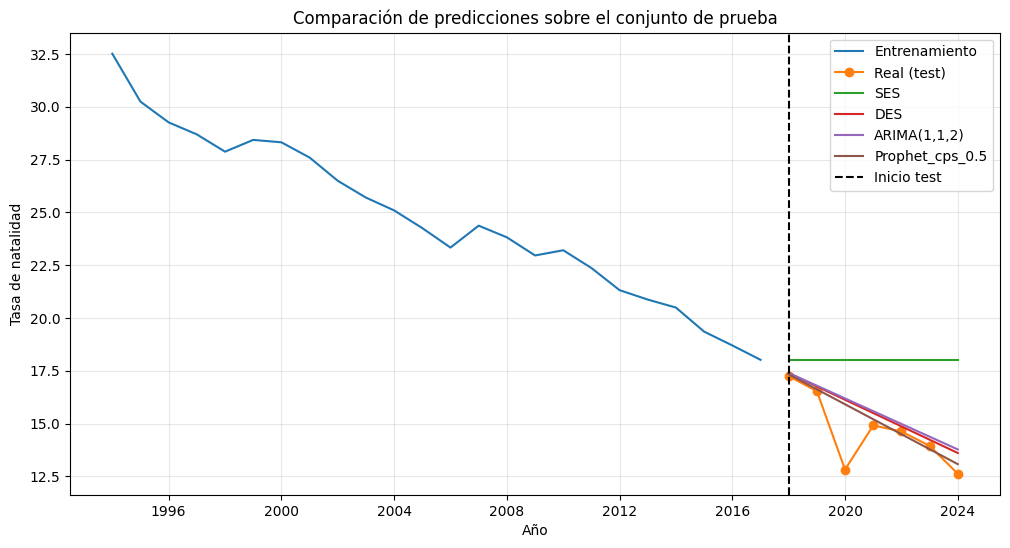

Mejor modelo por métricas para análisis de residuos: Prophet_cps_0.5


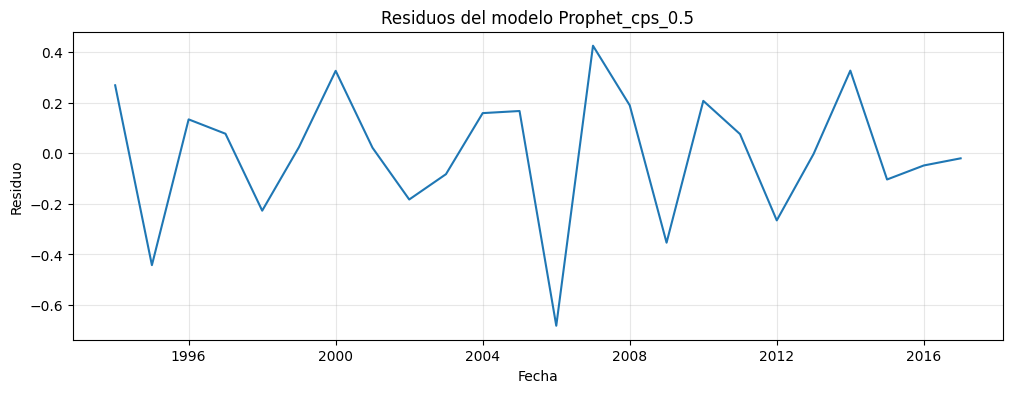

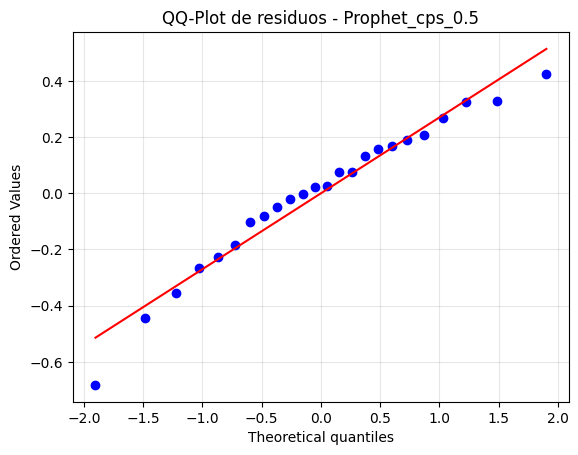

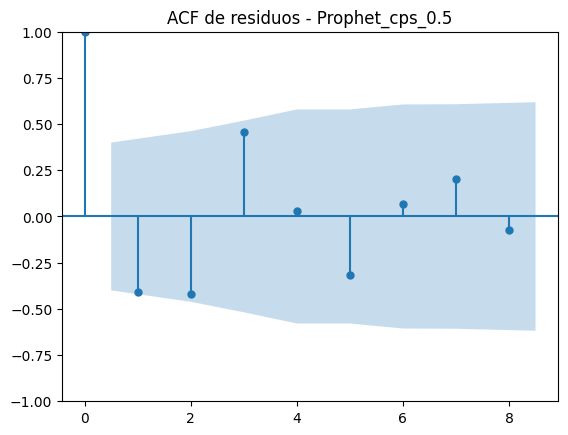

===> Test: Ljung-Box
H0: Ruido blanco
H1: Autocorrelación
p-value: 0.001999
Se RECHAZA H0
Evidencia a favor de: Autocorrelación

===> Test: Jarque-Bera
H0: Normalidad
H1: No normalidad
p-value: 0.351116
NO se rechaza H0
No hay evidencia suficiente contra: Normalidad

===> Test: ARCH
H0: Homocedasticidad
H1: Heterocedasticidad
p-value: 0.898415
NO se rechaza H0
No hay evidencia suficiente contra: Homocedasticidad

------------------------------------
Iniciando GridSearch para modelos ARIMA...
          Modelo      order         AIC         BIC
0   ARIMA(0,1,3)  (0, 1, 3)   54.034915   58.576892
1   ARIMA(1,1,1)  (1, 1, 1)   54.065546   57.472029
2   ARIMA(3,1,0)  (3, 1, 0)   55.673192   60.215169
3   ARIMA(2,1,2)  (2, 1, 2)   55.767618   61.445089
4   ARIMA(1,1,3)  (1, 1, 3)   55.802757   61.480228
5   ARIMA(1,1,2)  (1, 1, 2)   55.817658   60.359635
6   ARIMA(2,1,1)  (2, 1, 1)   55.932428   60.474405
7   ARIMA(3,1,2)  (3, 1, 2)   56.030399   62.843364
8   ARIMA(3,1,1)  (3, 1, 1)   57.03

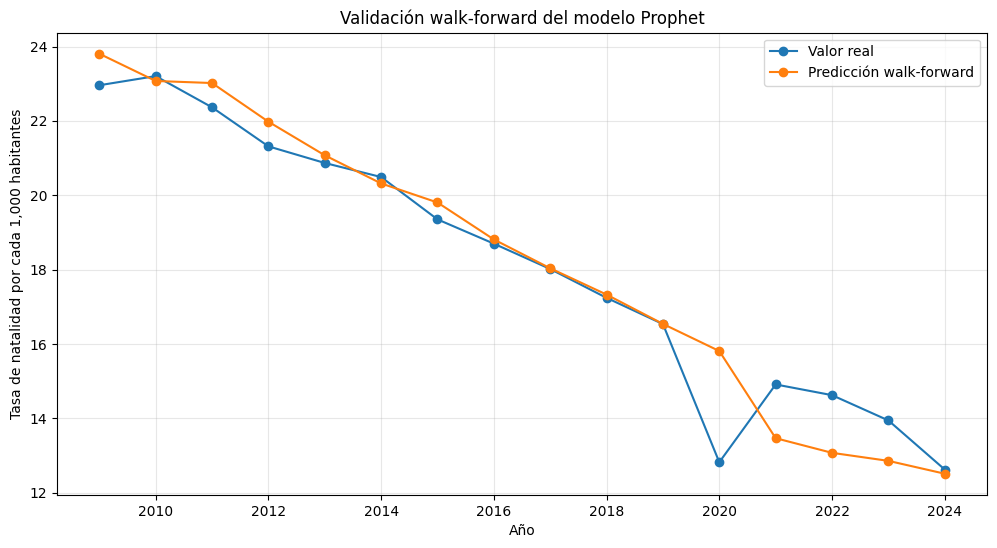

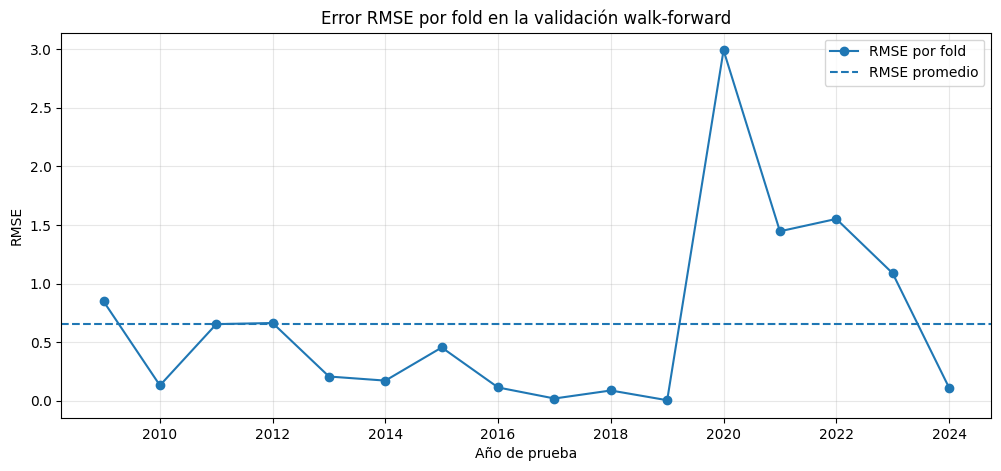

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats
import warnings
warnings.filterwarnings("ignore")

from sklearn.metrics import mean_absolute_error, mean_squared_error

from statsmodels.tsa.stattools import adfuller, kpss, acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.holtwinters import SimpleExpSmoothing, ExponentialSmoothing
from statsmodels.tsa.arima.model import ARIMA

from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch
from statsmodels.stats.stattools import jarque_bera

# Si Prophet no está instalado:
# !pip install prophet
from prophet import Prophet


# =========================================================
# CONFIGURACIÓN GENERAL
# =========================================================

DEBUG_SHOW_GRAPH = True
DEBUG_SHOW_GRAPH_CORRELOGRAM = True
DEBUG_SHOW_GRAPH_RESIDUALS = True


# =========================================================
# FUNCIONES AUXILIARES
# =========================================================

def interpretar_test(nombre, pvalue, alpha, H0, H1):
    print(f"===> Test: {nombre}")
    print(f"H0: {H0}")
    print(f"H1: {H1}")
    print(f"p-value: {pvalue:.6f}")

    if pvalue < alpha:
        print("Se RECHAZA H0")
        print(f"Evidencia a favor de: {H1}")
    else:
        print("NO se rechaza H0")
        print(f"No hay evidencia suficiente contra: {H0}")
    print("")


def adf_test(series):
    result = adfuller(series.dropna())
    interpretar_test(
        "ADF",
        result[1],
        0.05,
        "Serie NO estacionaria",
        "Serie estacionaria"
    )


def kpss_test(series):
    result = kpss(series.dropna(), regression="c", nlags="auto")
    interpretar_test(
        "KPSS",
        result[1],
        0.05,
        "Serie estacionaria",
        "Serie NO estacionaria"
    )


def metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    smape = 100 * np.mean(2 * np.abs(y_pred - y_true) / (np.abs(y_true) + np.abs(y_pred)))
    return mae, mse, rmse, mape, smape


# =========================================================
# 1.4.1 IMPLEMENTACIÓN DEL MODELO
# Preparación de la serie temporal de tasa de natalidad
# =========================================================

# Se parte del dataframe df_tasa, ya integrado previamente
# Columnas esperadas: ano, nacimientos_totales, poblacion_total, tasa_natalidad

df_model = df_tasa.copy()
df_model = df_model.sort_values("ano").reset_index(drop=True)

# Conversión de año a fecha para trabajar como serie temporal
df_model["fecha"] = pd.to_datetime(df_model["ano"].astype(int).astype(str) + "-01-01")

# Definición de la serie temporal
serie = df_model[["fecha", "tasa_natalidad"]].copy()
serie = serie.set_index("fecha")
serie = serie.asfreq("YS")

ts = serie["tasa_natalidad"]

print("Serie final:")
print(ts.head())
print(ts.tail())
print("Observaciones:", len(ts))


# Visualización de la serie original
if DEBUG_SHOW_GRAPH:
    plt.figure(figsize=(12, 4))
    plt.plot(ts, label="Tasa de natalidad")
    plt.title("Serie temporal original de la tasa de natalidad en México")
    plt.xlabel("Fecha")
    plt.ylabel("Tasa de natalidad")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()


# =========================================================
# Pruebas de estacionariedad
# =========================================================

print("------------------------------------")
print("Pruebas de estacionariedad para la serie original")
adf_test(ts)
kpss_test(ts)

print("------------------------------------")
print("Serie diferenciada de primer orden")
ts_diff = ts.diff().dropna()

if DEBUG_SHOW_GRAPH:
    plt.figure(figsize=(12, 4))
    plt.plot(ts_diff, label="Serie diferenciada")
    plt.title("Serie diferenciada de primer orden")
    plt.xlabel("Fecha")
    plt.ylabel("Cambio en la tasa de natalidad")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

print("Pruebas de estacionariedad para la serie diferenciada")
adf_test(ts_diff)
kpss_test(ts_diff)
print("------------------------------------")


# =========================================================
# ACF y PACF
# =========================================================

n = len(ts)

if DEBUG_SHOW_GRAPH_CORRELOGRAM:
    fig, ax = plt.subplots(1, 2, figsize=(12, 4))
    plot_acf(ts_diff, ax=ax[0], lags=min(10, n // 3))
    plot_pacf(ts_diff, ax=ax[1], lags=min(10, n // 3), method="ywm")
    ax[0].set_title("ACF de la serie diferenciada")
    ax[1].set_title("PACF de la serie diferenciada")
    plt.tight_layout()
    plt.show()

acf_vals = acf(ts_diff, nlags=min(10, n // 3))
pacf_vals = pacf(ts_diff, nlags=min(10, n // 3), method="ywm")

print("ACF:")
for i, val in enumerate(acf_vals):
    print(f"Lag {i}: {val:.4f}")

print("PACF:")
for i, val in enumerate(pacf_vals):
    print(f"Lag {i}: {val:.4f}")

print("------------------------------------")


# =========================================================
# División del conjunto de datos en entrenamiento y prueba
# =========================================================

train_size = int(len(ts) * 0.8)
train, test = ts[:train_size], ts[train_size:]

print(f"Tamaño train: {len(train)}")
print(f"Tamaño test: {len(test)}")
print(f"Inicio train: {train.index[0]}  Fin train: {train.index[-1]}")
print(f"Inicio test: {test.index[0]}  Fin test: {test.index[-1]}")
print("------------------------------------")


# =========================================================
# Ajuste de modelos base
# =========================================================

models = {}

# SES
models["SES"] = SimpleExpSmoothing(train).fit(optimized=True)

# DES (Holt)
models["DES"] = ExponentialSmoothing(
    train,
    trend="add",
    seasonal=None
).fit(optimized=True)

# ARIMA
models["ARIMA(1,1,1)"] = ARIMA(train, order=(1, 1, 1)).fit()
models["ARIMA(2,1,1)"] = ARIMA(train, order=(2, 1, 1)).fit()
models["ARIMA(1,1,2)"] = ARIMA(train, order=(1, 1, 2)).fit()
models["ARIMA(2,1,2)"] = ARIMA(train, order=(2, 1, 2)).fit()

# Prophet con diferentes configuraciones
prophet_train = train.reset_index()
prophet_train.columns = ["ds", "y"]

for cps in [0.01, 0.05, 0.1, 0.5]:
    model = Prophet(
      yearly_seasonality=False,
      weekly_seasonality=False,
      daily_seasonality=False,
      changepoint_prior_scale=cps,
      n_changepoints=10
  )
    model.fit(prophet_train)
    models[f"Prophet_cps_{cps}"] = model


# =========================================================
# 1.4.2 AJUSTES AL MODELO CON DIFERENTES CONFIGURACIONES
# Comparación de AIC y BIC para modelos que lo permiten
# =========================================================

results_aic_bic = []

for name, model in models.items():
    if hasattr(model, "aic") and hasattr(model, "bic"):
        results_aic_bic.append([name, model.aic, model.bic])

df_results = pd.DataFrame(
    results_aic_bic,
    columns=["Modelo", "AIC", "BIC"]
).sort_values(["AIC", "BIC"]).reset_index(drop=True)

print("Modelos ordenados por AIC y BIC:")
print(df_results)
print("------------------------------------")


# =========================================================
# 1.4.3 EVALUACIÓN DEL MODELO
# Pronósticos y métricas de desempeño
# =========================================================

pronosticos = {}
metricas_resultados = []

for name, model in models.items():
    if name.startswith("Prophet"):
        future = model.make_future_dataframe(periods=len(test), freq="YS")
        forecast = model.predict(future)
        pred_series = forecast.set_index("ds").loc[test.index, "yhat"]
    else:
        pred = model.forecast(steps=len(test))
        pred_series = pd.Series(pred.values, index=test.index)

    pronosticos[name] = pred_series

    mae, mse, rmse, mape, smape = metrics(test, pred_series)
    metricas_resultados.append([name, mae, mse, rmse, mape, smape])

df_metricas = pd.DataFrame(
    metricas_resultados,
    columns=["Modelo", "MAE", "MSE", "RMSE", "MAPE", "sMAPE"]
).sort_values(["RMSE", "MAE"]).reset_index(drop=True)

print("Métricas de desempeño:")
print(df_metricas)
print("")
print("Mejor modelo por métricas:")
print(df_metricas.iloc[0])
print("------------------------------------")

# =========================================================
# ESTABILIDAD DE ERRORES EN EL CONJUNTO TEST HOLD-OUT
# Para el mejor modelo: Prophet_cps_0.5
# =========================================================

best_holdout_name = df_metricas.iloc[0]["Modelo"]

df_errores_holdout = pd.DataFrame({
    "ano": test.index.year,
    "real": test.values,
    "predicho": pronosticos[best_holdout_name].values
})

df_errores_holdout["error"] = df_errores_holdout["real"] - df_errores_holdout["predicho"]
df_errores_holdout["error_absoluto"] = abs(df_errores_holdout["error"])
df_errores_holdout["error_cuadratico"] = df_errores_holdout["error"] ** 2
df_errores_holdout["MAPE_individual"] = (
    abs(df_errores_holdout["error"] / df_errores_holdout["real"]) * 100
)
df_errores_holdout["sMAPE_individual"] = (
    100 * (
        2 * abs(df_errores_holdout["predicho"] - df_errores_holdout["real"]) /
        (abs(df_errores_holdout["real"]) + abs(df_errores_holdout["predicho"]))
    )
)

print("=== ERRORES HOLD-OUT DEL MEJOR MODELO ===")
print(df_errores_holdout)

print("\n=== ESTABILIDAD DE ERRORES HOLD-OUT ===")
print("Error absoluto promedio:", df_errores_holdout["error_absoluto"].mean())
print("Desviación estándar del error absoluto:", df_errores_holdout["error_absoluto"].std(ddof=1))
print("MAPE promedio:", df_errores_holdout["MAPE_individual"].mean())
print("Desviación estándar del MAPE:", df_errores_holdout["MAPE_individual"].std(ddof=1))
print("sMAPE promedio:", df_errores_holdout["sMAPE_individual"].mean())
print("Desviación estándar del sMAPE:", df_errores_holdout["sMAPE_individual"].std(ddof=1))

df_errores_holdout.to_csv(
    "/content/drive/MyDrive/ClassFiles/Proyecto/errores_holdout_prophet.csv",
    index=False
)

# =========================================================
# Gráfica comparativa sobre el conjunto de prueba
# =========================================================

plt.figure(figsize=(12, 6))
plt.plot(train.index, train, label="Entrenamiento")
plt.plot(test.index, test, marker="o", label="Real (test)")

# Mostrar solo modelos más relevantes para no saturar la gráfica
for model_name in ["SES", "DES", "ARIMA(1,1,2)", "Prophet_cps_0.5"]:
    if model_name in pronosticos:
        plt.plot(pronosticos[model_name].index, pronosticos[model_name], label=model_name)

plt.axvline(x=test.index[0], color="black", linestyle="--", label="Inicio test")

plt.title("Comparación de predicciones sobre el conjunto de prueba")
plt.xlabel("Año")
plt.ylabel("Tasa de natalidad")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


# =========================================================
# 1.4.4 OPTIMIZACIÓN DE PARÁMETROS Y PRUEBAS AVANZADAS
# Diagnóstico de residuos del mejor modelo
# =========================================================

best_model_name = df_metricas.iloc[0]["Modelo"]
print(f"Mejor modelo por métricas para análisis de residuos: {best_model_name}")

if best_model_name.startswith("Prophet"):
    best_model = models[best_model_name]
    fitted_values = best_model.predict(prophet_train[["ds"]])["yhat"].values
    residuals = train.values - fitted_values
    residuals = pd.Series(residuals, index=train.index)
else:
    best_model = models[best_model_name]
    if hasattr(best_model, "fittedvalues"):
        residuals = train - best_model.fittedvalues
    else:
        residuals = pd.Series(best_model.resid, index=train.index[-len(best_model.resid):])

if DEBUG_SHOW_GRAPH_RESIDUALS:
    plt.figure(figsize=(12, 4))
    plt.plot(residuals)
    plt.title(f"Residuos del modelo {best_model_name}")
    plt.xlabel("Fecha")
    plt.ylabel("Residuo")
    plt.grid(alpha=0.3)
    plt.show()

    stats.probplot(residuals.dropna(), plot=plt)
    plt.title(f"QQ-Plot de residuos - {best_model_name}")
    plt.grid(alpha=0.3)
    plt.show()

    plot_acf(residuals.dropna(), lags=min(10, len(residuals.dropna()) // 3))
    plt.title(f"ACF de residuos - {best_model_name}")
    plt.show()


# Ljung-Box
lb = acorr_ljungbox(residuals.dropna(), lags=[5], return_df=True)
interpretar_test(
    "Ljung-Box",
    lb["lb_pvalue"].values[0],
    0.05,
    "Ruido blanco",
    "Autocorrelación"
)

# Jarque-Bera
jb = jarque_bera(residuals.dropna())
interpretar_test(
    "Jarque-Bera",
    jb[1],
    0.05,
    "Normalidad",
    "No normalidad"
)

# ARCH
arch_p = het_arch(residuals.dropna())[1]
interpretar_test(
    "ARCH",
    arch_p,
    0.05,
    "Homocedasticidad",
    "Heterocedasticidad"
)

print("------------------------------------")


# =========================================================
# Grid Search para ARIMA
# =========================================================

print("Iniciando GridSearch para modelos ARIMA...")

p_values = [0, 1, 2, 3]
d_values = [0, 1]
q_values = [0, 1, 2, 3]

grid_results = []

for p in p_values:
    for d in d_values:
        for q in q_values:
            try:
                model = ARIMA(train, order=(p, d, q)).fit()
                grid_results.append([
                    f"ARIMA({p},{d},{q})",
                    (p, d, q),
                    model.aic,
                    model.bic
                ])
            except:
                continue

df_grid_arima = pd.DataFrame(
    grid_results,
    columns=["Modelo", "order", "AIC", "BIC"]
).sort_values(["AIC", "BIC"]).reset_index(drop=True)

print(df_grid_arima)
print("Mejor ARIMA por GridSearch:")
print(df_grid_arima.iloc[0])

"""## Validación walk-forward y análisis de robustez del modelo seleccionado"""

# =========================================================
# 1.5.2 VALIDACIÓN WALK-FORWARD DEL MODELO SELECCIONADO
# Evaluación temporal con ventana expansiva
# =========================================================

# Esta validación permite evaluar la estabilidad del modelo Prophet
# simulando un escenario real: entrenar con información histórica disponible
# y pronosticar el siguiente año.

df_prophet_wf = ts.reset_index()
df_prophet_wf.columns = ["ds", "y"]

# Se define un tamaño mínimo de entrenamiento.
# En este caso, se usan los primeros 15 años para iniciar la validación.
initial_train_size = 15

walk_forward_results = []

for i in range(initial_train_size, len(df_prophet_wf)):

    # Datos disponibles hasta el año anterior
    train_wf = df_prophet_wf.iloc[:i].copy()

    # Año que se quiere pronosticar
    test_wf = df_prophet_wf.iloc[i:i+1].copy()

    # Modelo Prophet con la configuración seleccionada previamente
    model_wf = Prophet(
        yearly_seasonality=False,
        weekly_seasonality=False,
        daily_seasonality=False,
        changepoint_prior_scale=0.5,
        n_changepoints=10
    )

    # Entrenamiento con la ventana histórica disponible
    model_wf.fit(train_wf)

    # Pronóstico de un año hacia adelante
    future_wf = model_wf.make_future_dataframe(periods=1, freq="YS")
    forecast_wf = model_wf.predict(future_wf)

    # Predicción del año siguiente
    pred = forecast_wf.iloc[-1]["yhat"]
    real = test_wf.iloc[0]["y"]

    # Cálculo de errores del fold
    error = real - pred
    error_abs = abs(error)
    error_sq = error ** 2

    mae_fold = error_abs
    mse_fold = error_sq
    rmse_fold = np.sqrt(error_sq)
    mape_fold = abs(error / real) * 100
    smape_fold = 100 * (2 * abs(pred - real) / (abs(real) + abs(pred)))

    walk_forward_results.append({
        "fold": i - initial_train_size + 1,
        "train_inicio": train_wf.iloc[0]["ds"].year,
        "train_fin": train_wf.iloc[-1]["ds"].year,
        "ano_prueba": test_wf.iloc[0]["ds"].year,
        "real": real,
        "predicho": pred,
        "error": error,
        "error_absoluto": error_abs,
        "MAE": mae_fold,
        "RMSE": rmse_fold,
        "MSE": mse_fold,
        "MAPE(%)": mape_fold,
        "sMAPE(%)": smape_fold
    })

# Convertir resultados a dataframe
df_walk_forward = pd.DataFrame(walk_forward_results)

print("=== RESULTADOS DE VALIDACIÓN WALK-FORWARD POR FOLD ===")
print(df_walk_forward)


# =========================================================
# FUNCIÓN PARA RESUMIR ROBUSTEZ
# Promedio y desviación estándar de métricas por fold
# =========================================================

def summarize_robustness(metrics_df, model_name):
    summary = {"Modelo": model_name}
    metric_cols = ["MAE", "RMSE", "MSE", "MAPE(%)", "sMAPE(%)"]

    for col in metric_cols:
        summary[f"{col}_mean"] = metrics_df[col].mean()
        summary[f"{col}_std"] = metrics_df[col].std(ddof=1)

    return summary


summary_prophet = summarize_robustness(
    df_walk_forward,
    "Prophet_cps_0.5"
)

df_robustez_wf = pd.DataFrame([summary_prophet])

print("\n=== RESUMEN DE ROBUSTEZ WALK-FORWARD ===")
print(df_robustez_wf)


# =========================================================
# MÉTRICAS GLOBALES WALK-FORWARD
# Calculadas sobre todos los valores reales y predichos
# =========================================================

mae_wf, mse_wf, rmse_wf, mape_wf, smape_wf = metrics(
    df_walk_forward["real"],
    df_walk_forward["predicho"]
)

print("\n=== MÉTRICAS GLOBALES WALK-FORWARD ===")
print("MAE:", mae_wf)
print("RMSE:", rmse_wf)
print("MSE:", mse_wf)
print("MAPE:", mape_wf)
print("sMAPE:", smape_wf)


# =========================================================
# FOLD CON MAYOR ERROR
# =========================================================

fold_mayor_error = df_walk_forward.loc[df_walk_forward["RMSE"].idxmax()]

print("\n=== FOLD CON MAYOR ERROR ===")
print(fold_mayor_error)


# =========================================================
# GRÁFICA DE VALIDACIÓN WALK-FORWARD
# =========================================================

plt.figure(figsize=(12, 6))

plt.plot(
    df_walk_forward["ano_prueba"],
    df_walk_forward["real"],
    marker="o",
    label="Valor real"
)

plt.plot(
    df_walk_forward["ano_prueba"],
    df_walk_forward["predicho"],
    marker="o",
    label="Predicción walk-forward"
)

plt.title("Validación walk-forward del modelo Prophet")
plt.xlabel("Año")
plt.ylabel("Tasa de natalidad por cada 1,000 habitantes")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


# =========================================================
# GRÁFICA DE ERROR POR FOLD
# =========================================================

plt.figure(figsize=(12, 5))

plt.plot(
    df_walk_forward["ano_prueba"],
    df_walk_forward["RMSE"],
    marker="o",
    label="RMSE por fold"
)

plt.axhline(
    y=df_walk_forward["RMSE"].mean(),
    linestyle="--",
    label="RMSE promedio"
)

plt.title("Error RMSE por fold en la validación walk-forward")
plt.xlabel("Año de prueba")
plt.ylabel("RMSE")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


# =========================================================
# GUARDAR RESULTADOS
# =========================================================

df_walk_forward.to_csv(
    "/content/drive/MyDrive/ClassFiles/Proyecto/validacion_walk_forward_por_fold_prophet.csv",
    index=False
)

df_robustez_wf.to_csv(
    "/content/drive/MyDrive/ClassFiles/Proyecto/resumen_robustez_walk_forward_prophet.csv",
    index=False
)

##Pronóstico final a 5 y 10 años

=== PRONÓSTICO DE TASA DE NATALIDAD A 10 AÑOS ===
     ano  tasa_pronosticada  limite_inferior  limite_superior
31  2025          11.790058        10.976672        12.561288
32  2026          11.041095        10.165227        11.830988
33  2027          10.292133         9.356140        11.156985
34  2028           9.543170         8.329314        10.520101
35  2029           8.792155         7.325053         9.889036
36  2030           8.043192         6.258187         9.613678
37  2031           7.294229         5.174732         8.990280
38  2032           6.545267         3.806295         8.744489
39  2033           5.794252         2.566056         8.468832
40  2034           5.045289         1.173355         8.179525

=== PRONÓSTICO DE TASA DE NATALIDAD A 5 AÑOS ===
     ano  tasa_pronosticada  limite_inferior  limite_superior
31  2025          11.790058        10.976672        12.561288
32  2026          11.041095        10.165227        11.830988
33  2027          10.292133     

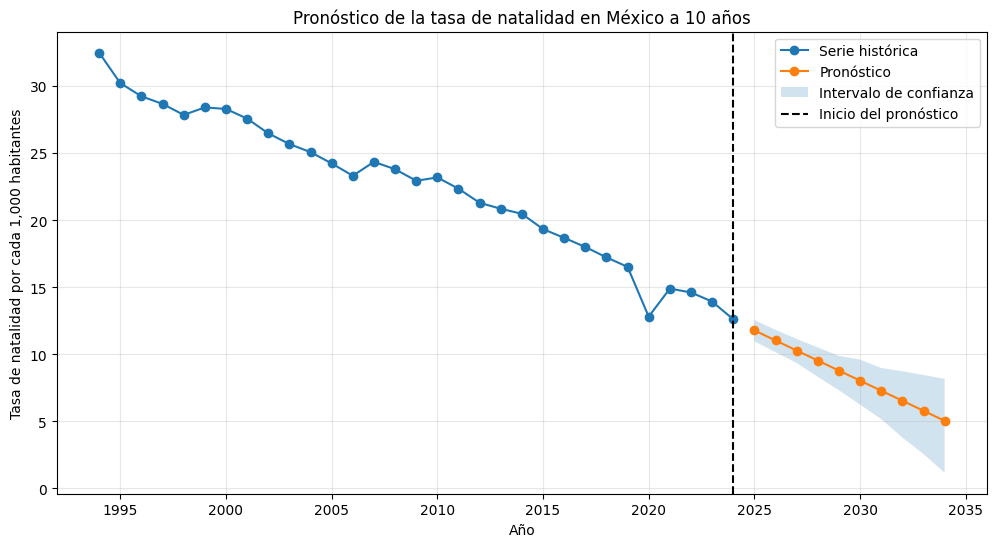

In [ ]:
# =========================================================
# 2.3 PRONÓSTICO FINAL A 5 Y 10 AÑOS
# Reentrenamiento del mejor modelo con toda la serie disponible
# =========================================================

# Se utiliza el mejor modelo identificado previamente:
# Prophet con changepoint_prior_scale = 0.5

prophet_full = ts.reset_index()
prophet_full.columns = ["ds", "y"]

modelo_final = Prophet(
    yearly_seasonality=False,
    weekly_seasonality=False,
    daily_seasonality=False,
    changepoint_prior_scale=0.5,
    n_changepoints=10
)

# Entrenar el modelo final con toda la serie histórica disponible
modelo_final.fit(prophet_full)

# Crear dataframe futuro para 10 años
# Como la serie llega hasta 2024, el pronóstico será 2025–2034
future_10 = modelo_final.make_future_dataframe(periods=10, freq="YS")

# Generar pronóstico
forecast_10 = modelo_final.predict(future_10)

# Filtrar solo los años futuros
pronostico_futuro = forecast_10[forecast_10["ds"] > prophet_full["ds"].max()].copy()

# Agregar columna de año
pronostico_futuro["ano"] = pronostico_futuro["ds"].dt.year

# Seleccionar columnas principales
pronostico_futuro = pronostico_futuro[[
    "ano",
    "yhat",
    "yhat_lower",
    "yhat_upper"
]]

# Renombrar columnas para presentación
pronostico_futuro = pronostico_futuro.rename(columns={
    "yhat": "tasa_pronosticada",
    "yhat_lower": "limite_inferior",
    "yhat_upper": "limite_superior"
})

print("=== PRONÓSTICO DE TASA DE NATALIDAD A 10 AÑOS ===")
print(pronostico_futuro)

# Separar pronóstico a 5 años
pronostico_5 = pronostico_futuro[pronostico_futuro["ano"].between(2025, 2029)].copy()

print("\n=== PRONÓSTICO DE TASA DE NATALIDAD A 5 AÑOS ===")
print(pronostico_5)

# =========================================================
# GRÁFICA DEL PRONÓSTICO FINAL A 10 AÑOS
# =========================================================

plt.figure(figsize=(12, 6))

# Serie histórica
plt.plot(
    prophet_full["ds"],
    prophet_full["y"],
    label="Serie histórica",
    marker="o"
)

# Fechas futuras
fechas_futuras = pd.to_datetime(pronostico_futuro["ano"].astype(str) + "-01-01")

# Pronóstico futuro
plt.plot(
    fechas_futuras,
    pronostico_futuro["tasa_pronosticada"],
    label="Pronóstico",
    marker="o"
)

# Intervalo de confianza
plt.fill_between(
    fechas_futuras,
    pronostico_futuro["limite_inferior"],
    pronostico_futuro["limite_superior"],
    alpha=0.2,
    label="Intervalo de confianza"
)

plt.axvline(
    x=prophet_full["ds"].max(),
    color="black",
    linestyle="--",
    label="Inicio del pronóstico"
)

plt.title("Pronóstico de la tasa de natalidad en México a 10 años")
plt.xlabel("Año")
plt.ylabel("Tasa de natalidad por cada 1,000 habitantes")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# Guardar resultados del pronóstico
pronostico_futuro.to_csv(
    "/content/drive/MyDrive/ClassFiles/Proyecto/pronostico_tasa_natalidad_2025_2034.csv",
    index=False
)